# AUC-ROC Evaluation | Anomaly Detection Benchmark

Evaluates all four anomaly detection methods against synthetic ground truth on **injected datasets**.

**Methods evaluated:**
- Cosine Similarity (global anomaly score)
- Sliced Wasserstein Distance (painting-level SWD)
- Kolmogorov-Smirnov Test (mean KS-D statistic)
- Isolation Forest (global normalised score)

**Genres:** Impressionism · Realism · Romanticism

Ground truth: `is_anomaly` in `embeddings/<genre>/injected/metadata.csv`  
Scores: `results/<genre>/injected/` CSV files produced by each method notebook.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — add/remove genres here if needed                    ║
# ╚══════════════════════════════════════════════════════════════════════╝
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))
from config import GENRES, EMBEDDINGS_DIR, RESULTS_DIR

OUT_DIR = RESULTS_DIR / "auc_evaluation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output dir : {OUT_DIR}")
print(f"Genres     : {GENRES}")

Output dir : ..\results\auc_evaluation
Genres     : ['impressionism', 'realism', 'romanticism']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
)

## Load Scores and Ground Truth

Join score CSVs from all four method notebooks with the injected metadata ground truth.


In [ ]:
from config import genre_dataset_dir, genre_results_dir

def load_genre_data(genre: str) -> pd.DataFrame:
    meta_path = genre_dataset_dir(genre, "injected") / "metadata.csv"
    r_dir     = genre_results_dir(genre, "injected")

    meta   = pd.read_csv(meta_path)[["filename", "is_anomaly", "anomaly_genre"]]
    cosine = pd.read_csv(r_dir / "phase1_global_cosine_scores.csv")[["filename", "global_anomaly_score"]]
    swd    = pd.read_csv(r_dir / "wasserstein_phase2_painting_scores.csv")[["filename", "painting_swd_norm"]]
    ks     = pd.read_csv(r_dir / "ks_phase2_painting_scores.csv")[["filename", "ks_mean_d"]]
    if_    = pd.read_csv(r_dir / "if_phase1_global_scores.csv")[["filename", "if_global_norm"]]

    df = meta.copy()
    for scores in [cosine, swd, ks, if_]:
        df = df.merge(scores, on="filename", how="left")
    df["genre"] = genre
    return df

genre_dfs = {g: load_genre_data(g) for g in GENRES}

for genre, df in genre_dfs.items():
    n = df["is_anomaly"].sum()
    print(f"{genre:<15} {len(df):>5} rows | anomalies: {n} ({n/len(df):.1%}) | "
          f"NaN: cosine={df.global_anomaly_score.isna().sum()} "
          f"swd={df.painting_swd_norm.isna().sum()} "
          f"ks={df.ks_mean_d.isna().sum()} "
          f"if={df.if_global_norm.isna().sum()}")

impressionism    1575 rows | anomalies: 75 (4.8%) | NaN: cosine=0 swd=0 ks=0 if=0
realism          1575 rows | anomalies: 75 (4.8%) | NaN: cosine=0 swd=0 ks=0 if=0
romanticism      1575 rows | anomalies: 75 (4.8%) | NaN: cosine=0 swd=0 ks=0 if=0


## AUC-ROC and Average Precision Per Genre

Higher AUC = better at ranking true anomalies above normal paintings.  
Random baseline = 0.50 AUC / AP ≈ 0.05 (contamination rate).


In [4]:
METHODS = {
    "Cosine Similarity":    "global_anomaly_score",
    "Wasserstein Distance": "painting_swd_norm",
    "KS Test":              "ks_mean_d",
    "Isolation Forest":     "if_global_norm",
}

METHOD_COLORS = {
    "Cosine Similarity":    "steelblue",
    "Wasserstein Distance": "darkorange",
    "KS Test":              "forestgreen",
    "Isolation Forest":     "crimson",
}

records = []
for genre, df in genre_dfs.items():
    y_true = df["is_anomaly"].values
    for method, col in METHODS.items():
        scores = df[col].fillna(df[col].median()).values
        auc = roc_auc_score(y_true, scores)
        ap  = average_precision_score(y_true, scores)
        records.append({"genre": genre, "method": method, "AUC-ROC": auc, "Avg Precision": ap})

results_df = pd.DataFrame(records)

pivot = results_df.pivot(index="method", columns="genre", values="AUC-ROC").round(4)
pivot["Mean AUC"] = pivot.mean(axis=1)
pivot = pivot.sort_values("Mean AUC", ascending=False)
print("AUC-ROC scores (higher is better):\n")
print(pivot.to_string())


AUC-ROC scores (higher is better):

genre                 impressionism  realism  romanticism  Mean AUC
method                                                             
Cosine Similarity            0.8341   0.7507       0.7997  0.794833
KS Test                      0.7823   0.6544       0.7882  0.741633
Wasserstein Distance         0.3930   0.3422       0.4690  0.401400
Isolation Forest             0.4589   0.3020       0.3790  0.379967


## ROC Curves Per Genre


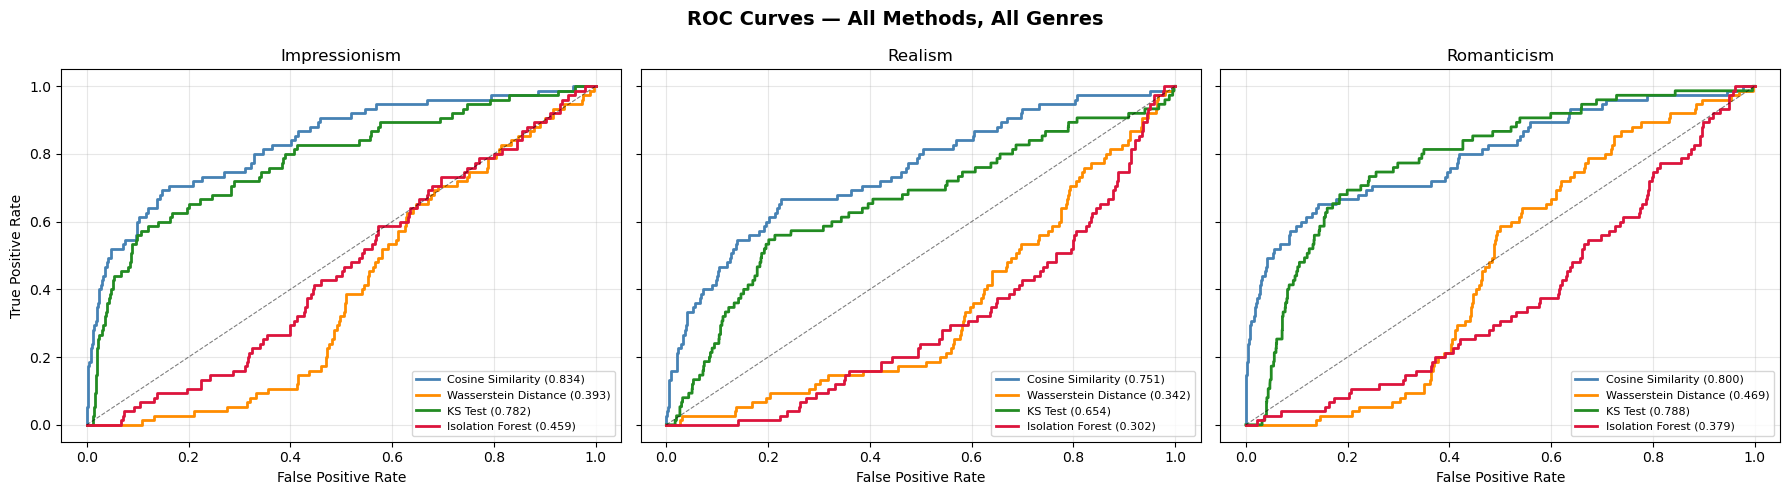

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, genre in zip(axes, GENRES):
    df     = genre_dfs[genre]
    y_true = df["is_anomaly"].values
    for method, col in METHODS.items():
        scores      = df[col].fillna(df[col].median()).values
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc         = roc_auc_score(y_true, scores)
        ax.plot(fpr, tpr, label=f"{method} ({auc:.3f})",
                color=METHOD_COLORS[method], linewidth=2)
    ax.plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.5)
    ax.set_title(genre.title(), fontsize=12)
    ax.set_xlabel("False Positive Rate")
    if ax is axes[0]:
        ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)

fig.suptitle("ROC Curves — All Methods, All Genres", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_curves_all_genres.png", dpi=150)
plt.show()


## Precision-Recall Curves Per Genre

PR curves are more informative under class imbalance (5% anomalies).  
A random classifier achieves AP ≈ contamination rate (dashed baseline).


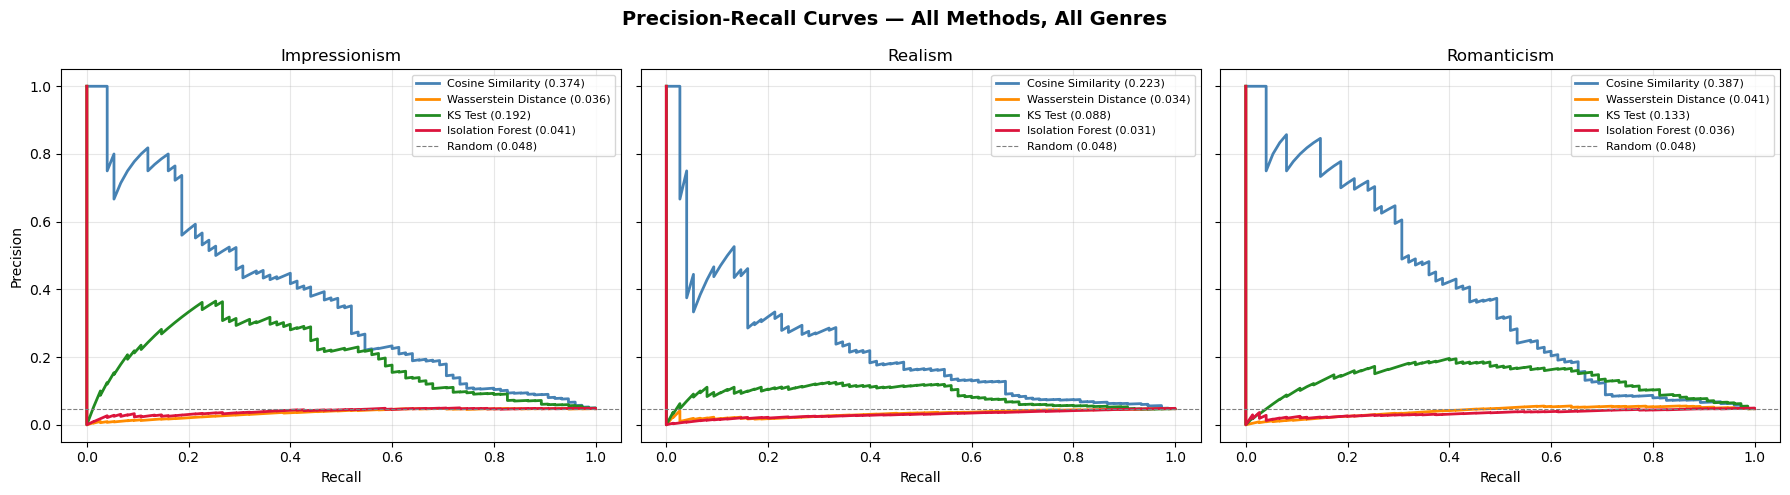

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, genre in zip(axes, GENRES):
    df       = genre_dfs[genre]
    y_true   = df["is_anomaly"].values
    baseline = y_true.mean()
    for method, col in METHODS.items():
        scores        = df[col].fillna(df[col].median()).values
        prec, rec, _  = precision_recall_curve(y_true, scores)
        ap            = average_precision_score(y_true, scores)
        ax.plot(rec, prec, label=f"{method} ({ap:.3f})",
                color=METHOD_COLORS[method], linewidth=2)
    ax.axhline(baseline, color="gray", linestyle="--",
               linewidth=0.8, label=f"Random ({baseline:.3f})")
    ax.set_title(genre.title(), fontsize=12)
    ax.set_xlabel("Recall")
    if ax is axes[0]:
        ax.set_ylabel("Precision")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

fig.suptitle("Precision-Recall Curves — All Methods, All Genres",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "pr_curves_all_genres.png", dpi=150)
plt.show()


## AUC-ROC Heatmap


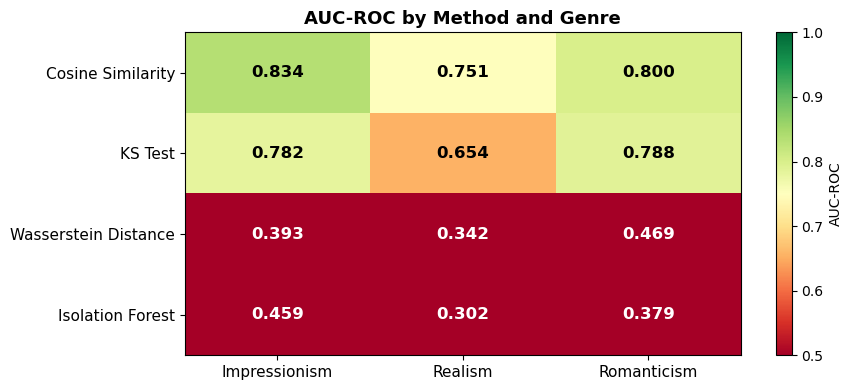

In [7]:
auc_pivot = results_df.pivot(index="method", columns="genre", values="AUC-ROC")
auc_pivot = auc_pivot[GENRES]
method_order = pivot.index.tolist()
if "Mean AUC" in method_order:
    method_order.remove("Mean AUC")
auc_pivot = auc_pivot.loc[method_order]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(auc_pivot.values, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=ax, label="AUC-ROC")
ax.set_xticks(range(len(GENRES)))
ax.set_xticklabels([g.title() for g in GENRES], fontsize=11)
ax.set_yticks(range(len(auc_pivot)))
ax.set_yticklabels(auc_pivot.index, fontsize=11)
for i in range(len(auc_pivot)):
    for j in range(len(GENRES)):
        val   = auc_pivot.values[i, j]
        color = "black" if 0.55 < val < 0.90 else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)
ax.set_title("AUC-ROC by Method and Genre", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "aucroc_heatmap.png", dpi=150)
plt.show()


## Average Precision Heatmap


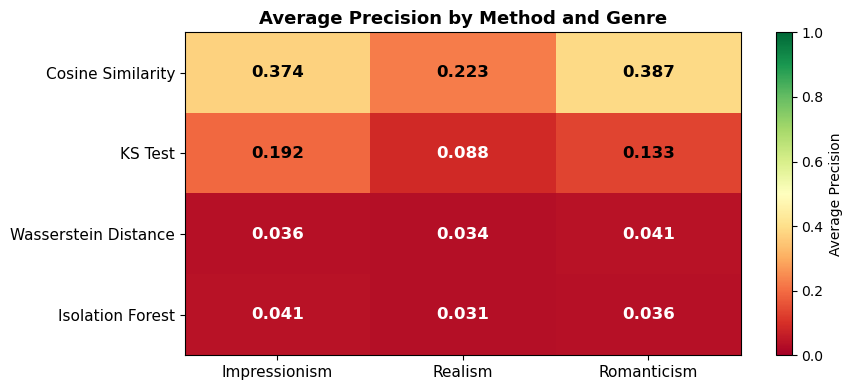

In [8]:
ap_pivot = results_df.pivot(index="method", columns="genre", values="Avg Precision")
ap_pivot = ap_pivot[GENRES].loc[method_order]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(ap_pivot.values, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=ax, label="Average Precision")
ax.set_xticks(range(len(GENRES)))
ax.set_xticklabels([g.title() for g in GENRES], fontsize=11)
ax.set_yticks(range(len(ap_pivot)))
ax.set_yticklabels(ap_pivot.index, fontsize=11)
for i in range(len(ap_pivot)):
    for j in range(len(GENRES)):
        val   = ap_pivot.values[i, j]
        color = "black" if 0.10 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)
ax.set_title("Average Precision by Method and Genre", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "avg_precision_heatmap.png", dpi=150)
plt.show()


## Score Distributions: Anomaly vs Normal

Separation between the two distributions indicates how well each method
assigns higher anomaly scores to injected outliers.


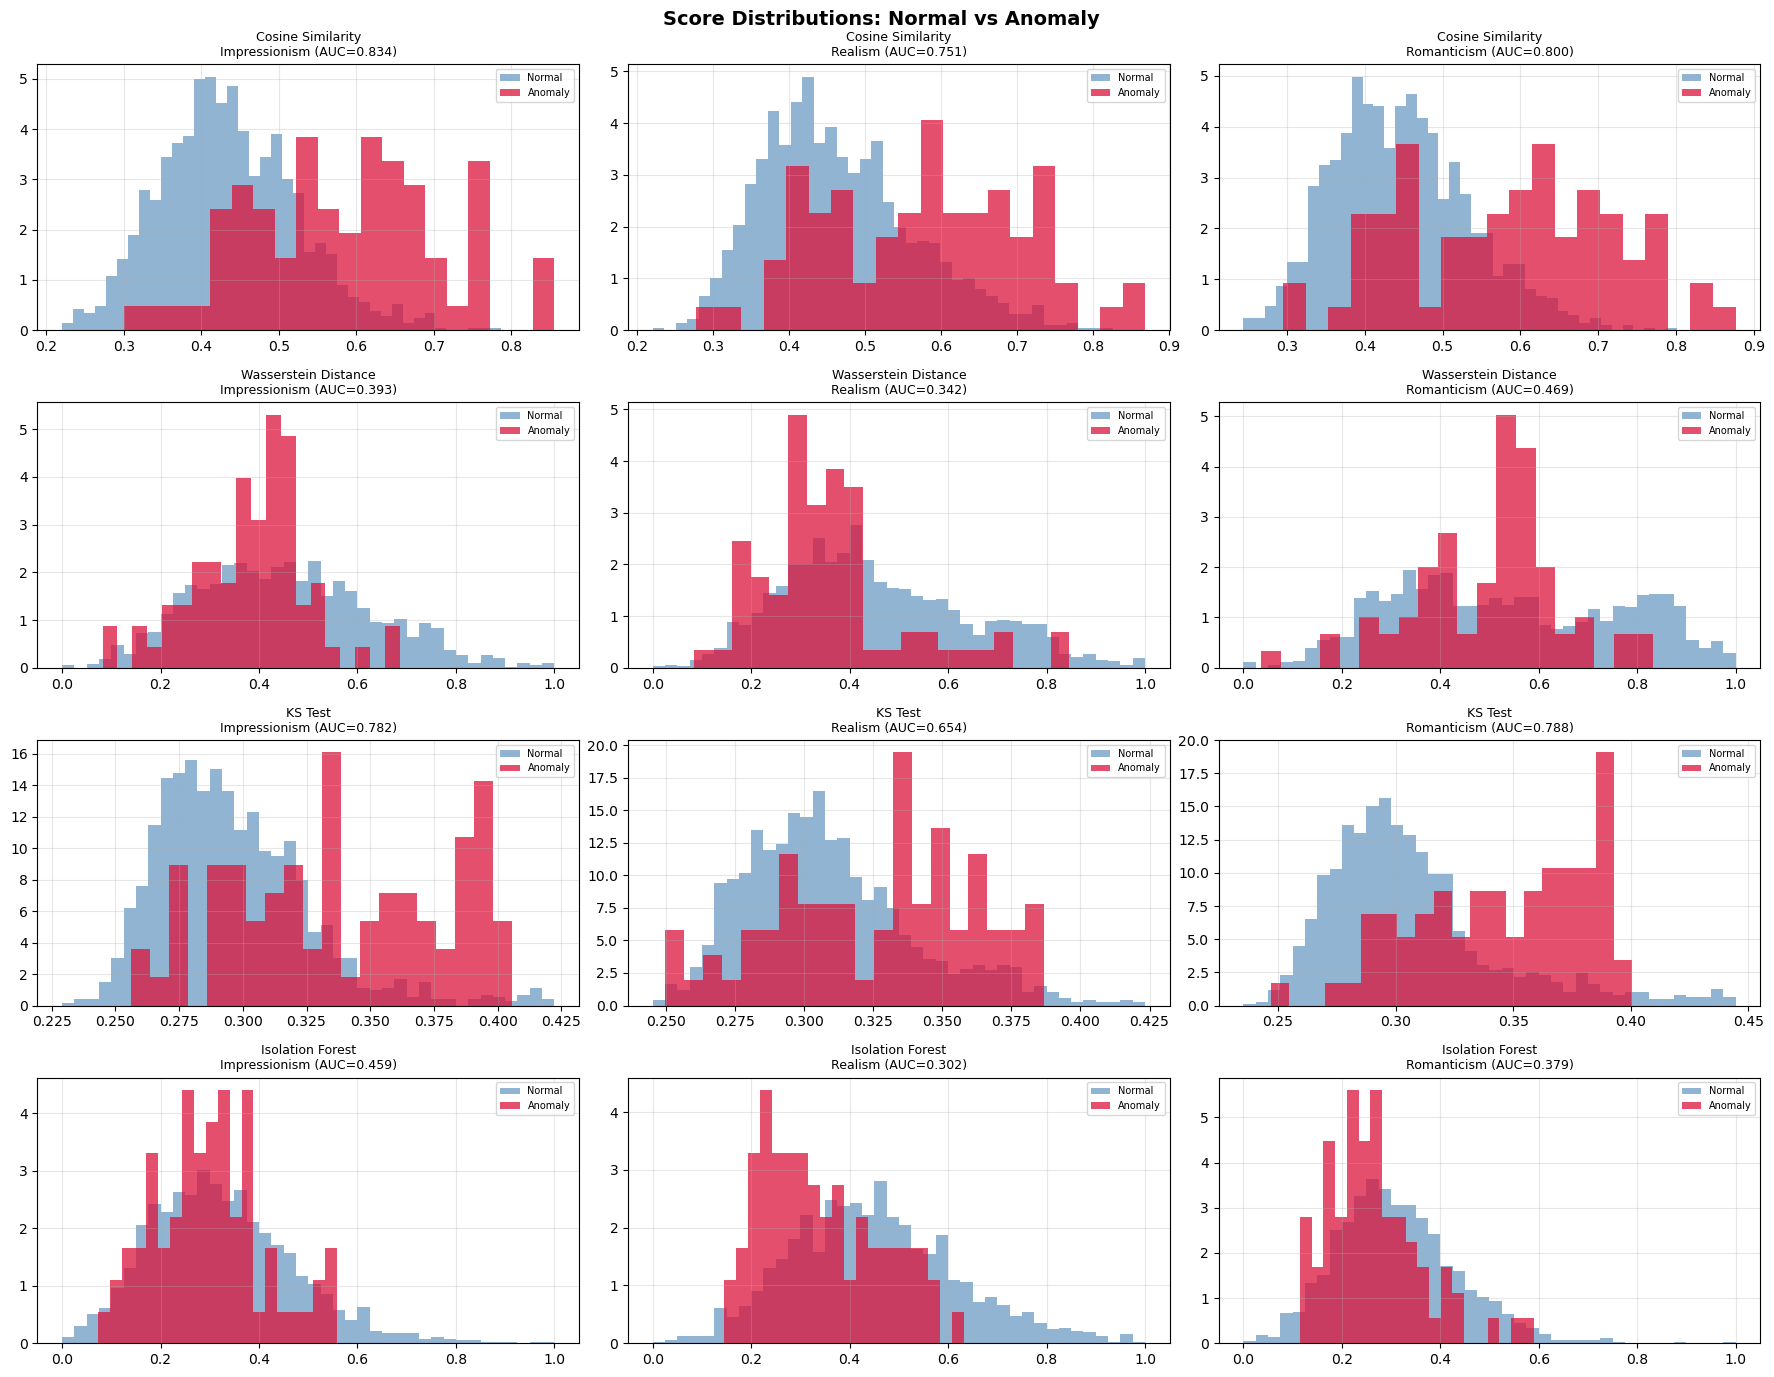

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))

for row, (method, col) in enumerate(METHODS.items()):
    for col_i, genre in enumerate(GENRES):
        ax = axes[row][col_i]
        df = genre_dfs[genre]
        med = df[col].median()
        normal  = df.loc[df["is_anomaly"]==0, col].fillna(med)
        anomaly = df.loc[df["is_anomaly"]==1, col].fillna(med)
        ax.hist(normal,  bins=40, alpha=0.6, color="steelblue",
                label="Normal",  density=True)
        ax.hist(anomaly, bins=20, alpha=0.75, color="crimson",
                label="Anomaly", density=True)
        auc = roc_auc_score(df["is_anomaly"].values, df[col].fillna(med).values)
        ax.set_title(f"{method}\n{genre.title()} (AUC={auc:.3f})", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

fig.suptitle("Score Distributions: Normal vs Anomaly", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "score_distributions_all.png", dpi=150)
plt.show()


## Precision@K

Of the top-K highest-scored paintings, what fraction are true anomalies?  
With 75 anomalies in 1575 paintings, a perfect detector captures all 75 by K=75.


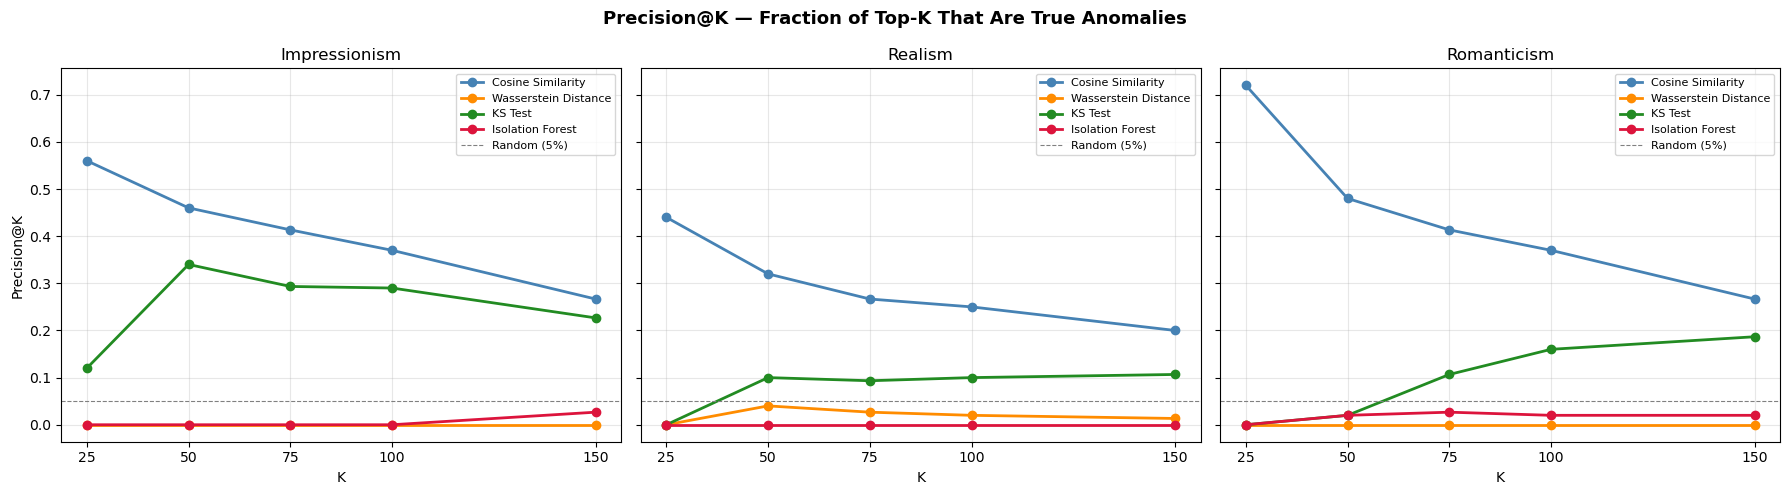

In [10]:
K_VALUES = [25, 50, 75, 100, 150]

topk_records = []
for genre, df in genre_dfs.items():
    y_true = df["is_anomaly"].values
    for method, col in METHODS.items():
        scores     = df[col].fillna(df[col].median()).values
        ranked_idx = np.argsort(scores)[::-1]
        for k in K_VALUES:
            top_k_labels = y_true[ranked_idx[:k]]
            topk_records.append({
                "genre": genre, "method": method, "K": k,
                "Precision@K": top_k_labels.sum() / k,
                "Recall@K":    top_k_labels.sum() / y_true.sum(),
            })

topk_df = pd.DataFrame(topk_records)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, genre in zip(axes, GENRES):
    sub = topk_df[topk_df["genre"]==genre]
    for method in METHODS:
        m = sub[sub["method"]==method]
        ax.plot(m["K"], m["Precision@K"], marker="o",
                label=method, color=METHOD_COLORS[method], linewidth=2)
    ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="Random (5%)")
    ax.set_title(genre.title())
    ax.set_xlabel("K")
    if ax is axes[0]:
        ax.set_ylabel("Precision@K")
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Precision@K — Fraction of Top-K That Are True Anomalies",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "precision_at_k.png", dpi=150)
plt.show()


## Full Benchmark Summary


In [11]:
summary_wide = results_df.pivot(index="method", columns="genre",
                                 values=["AUC-ROC", "Avg Precision"])
summary_wide.columns = [f"{m} ({g})" for m, g in summary_wide.columns]
summary_wide["Mean AUC"] = results_df.groupby("method")["AUC-ROC"].mean().round(4)
summary_wide["Mean AP"]  = results_df.groupby("method")["Avg Precision"].mean().round(4)
summary_wide            = summary_wide.sort_values("Mean AUC", ascending=False).round(4)

print("Full benchmark results:\n")
print(summary_wide.to_string())

summary_wide.to_csv(OUT_DIR / "benchmark_summary.csv")
print(f"\nSaved → {OUT_DIR}/benchmark_summary.csv")


Full benchmark results:

                      AUC-ROC (impressionism)  AUC-ROC (realism)  AUC-ROC (romanticism)  Avg Precision (impressionism)  Avg Precision (realism)  Avg Precision (romanticism)  Mean AUC  Mean AP
method                                                                                                                                                                                         
Cosine Similarity                      0.8341             0.7507                 0.7997                         0.3743                   0.2229                       0.3868    0.7949   0.3280
KS Test                                0.7823             0.6544                 0.7882                         0.1921                   0.0880                       0.1329    0.7416   0.1376
Wasserstein Distance                   0.3930             0.3422                 0.4690                         0.0361                   0.0340                       0.0413    0.4014   0.0371
Isolation Fores

## Best Method Per Genre & Overall Ranking


In [12]:
best_per_genre = results_df.loc[results_df.groupby("genre")["AUC-ROC"].idxmax()]
print("Best method per genre (AUC-ROC):")
print(best_per_genre[["genre","method","AUC-ROC","Avg Precision"]].to_string(index=False))
print()

overall = results_df.groupby("method")["AUC-ROC"].mean().sort_values(ascending=False)
print("Overall ranking (mean AUC-ROC across all genres):")
for rank, (method, score) in enumerate(overall.items(), 1):
    marker = " <-- best" if rank == 1 else ""
    print(f"  {rank}. {method:<30} {score:.4f}{marker}")


Best method per genre (AUC-ROC):
        genre            method  AUC-ROC  Avg Precision
impressionism Cosine Similarity 0.834107       0.374301
      realism Cosine Similarity 0.750738       0.222940
  romanticism Cosine Similarity 0.799742       0.386816

Overall ranking (mean AUC-ROC across all genres):
  1. Cosine Similarity              0.7949 <-- best
  2. KS Test                        0.7416
  3. Wasserstein Distance           0.4014
  4. Isolation Forest               0.3800
